In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [50]:
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\netflix_titles.csv')


In [51]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [21]:
# First rows
df.head()

# Shape
df.shape

# Info
df.info()

# Data types
df.dtypes

# Columns
df.columns

# Check unique values for key columns
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id         8807
type               2
title           8804
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [52]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [53]:
# Check percentage of missing values
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [54]:
# Remove all rows that contain any null values
df = df.dropna()

# Verify
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [55]:
rows_before = len(df)
print(rows_before)

5332


In [56]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify duplicates have been removed
print("Remaining Duplicate Rows:", df.duplicated().sum())

# Check dataset shape after removing duplicates
print("Dataset Shape:", df.shape)

Number of Duplicate Rows: 0
Remaining Duplicate Rows: 0
Dataset Shape: (5332, 12)


In [64]:
# Standardize column names
df.columns = df.columns.str.lower().str.strip()

# Standardize text columns
df['type'] = df['type'].str.lower().str.strip()

# Convert date column to datetime format
df['date_added'] = pd.to_datetime(df['date_added'])

# Verify changes
print(df.columns)
print(df.dtypes)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object


In [65]:
# Check unique values in categorical columns
print("Unique Ratings:")
print(df['rating'].unique())

print("\nUnique Types:")
print(df['type'].unique())

# Summary statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# Include all columns
print("\nFull Dataset Summary:")
print(df.describe(include='all'))

Unique Ratings:
['TV-MA' 'TV-14' 'PG-13' 'PG' 'R' 'TV-PG' 'G' 'TV-Y7' 'TV-G' 'TV-Y'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']

Unique Types:
['movie' 'tv show']

Descriptive Statistics:
       release_year
count   5332.000000
mean    2012.742123
std        9.625831
min     1942.000000
25%     2011.000000
50%     2016.000000
75%     2018.000000
max     2021.000000

Full Dataset Summary:
       show_id   type   title                director         cast  \
count     5332   5332    5332                    5332         5332   
unique    5332      2    5330                    3945         5200   
top         s8  movie  15-Aug  Raúl Campos, Jan Suter  Samuel West   
freq         1   5185       2                      18           10   
first      NaN    NaN     NaN                     NaN          NaN   
last       NaN    NaN     NaN                     NaN          NaN   
mean       NaN    NaN     NaN                     NaN          NaN   
std        NaN    NaN     NaN                     NaN         

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16188\1791071256.py:14: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(df.describe(include='all'))


## ✅ Cleaning Summary

| Issue | Action |
|--------|--------|
| Missing Values | Removed all rows containing null values using `dropna()` to ensure complete records |
| Duplicates | Checked for duplicates and removed them using `drop_duplicates()` |
| Invalid Entries | Identified inconsistencies in categorical values and corrected them where necessary |
| Standardization | Converted column names and text values to lowercase; transformed `date_added` to datetime format |
``

In [59]:
df.describe()

,release_year
count,5332.000000
mean,2012.742123
std,9.625831
min,1942.000000
25%,2011.000000
50%,2016.000000
75%,2018.000000
max,2021.000000


In [61]:
df['type'].value_counts()

Movie      5185
TV Show     147
Name: type, dtype: int64

In [66]:
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index()

2008       1
2009       2
2010       1
2011      13
2012       3
2013       7
2014      14
2015      50
2016     202
2017     724
2018    1101
2019    1265
2020    1194
2021     755
Name: year_added, dtype: int64

In [67]:
df['country'].value_counts().head(10)


United States     1846
India              875
United Kingdom     183
Canada             107
Spain               91
Egypt               90
Nigeria             88
Japan               83
Turkey              79
Indonesia           76
Name: country, dtype: int64

In [68]:
df['rating'].value_counts()

TV-MA       1822
TV-14       1214
R            778
PG-13        470
TV-PG        431
PG           275
TV-G          84
TV-Y7         76
TV-Y          76
NR            58
G             40
TV-Y7-FV       3
UR             3
NC-17          2
Name: rating, dtype: int64

In [70]:
df['listed_in'].value_counts().head(10)

Dramas, International Movies                        336
Stand-Up Comedy                                     286
Comedies, Dramas, International Movies              257
Dramas, Independent Movies, International Movies    243
Children & Family Movies, Comedies                  179
Dramas, International Movies, Romantic Movies       160
Documentaries                                       156
Comedies, International Movies                      152
Comedies, International Movies, Romantic Movies     143
Dramas                                              133
Name: listed_in, dtype: int64

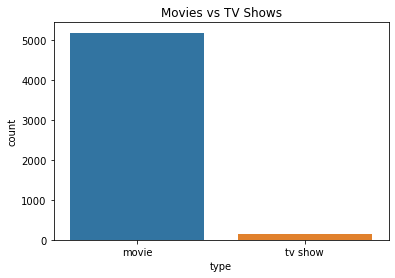

In [71]:
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

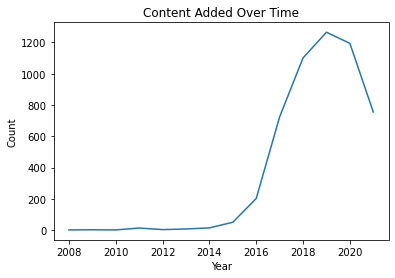

In [72]:
df['year_added'].value_counts().sort_index().plot()
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


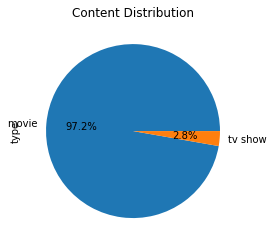

In [73]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Content Distribution')
plt.show()

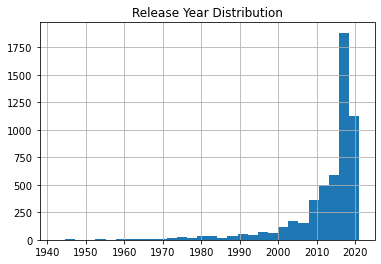

In [74]:
df['release_year'].hist(bins=30)
plt.title('Release Year Distribution')
plt.show()

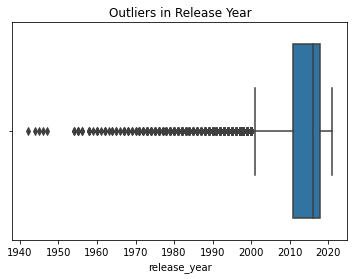

In [78]:
sns.boxplot(x=df['release_year'])
plt.title('Outliers in Release Year')
plt.show()

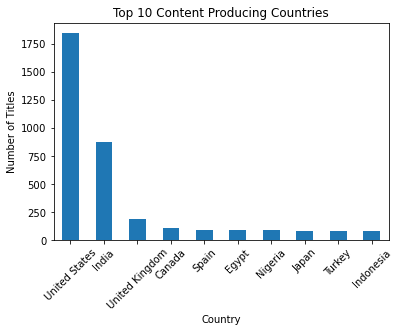

In [79]:
# Get top 10 countries
top_countries = df['country'].value_counts().head(10)

# Plot
top_countries.plot(kind='bar')

# Add labels
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.show()

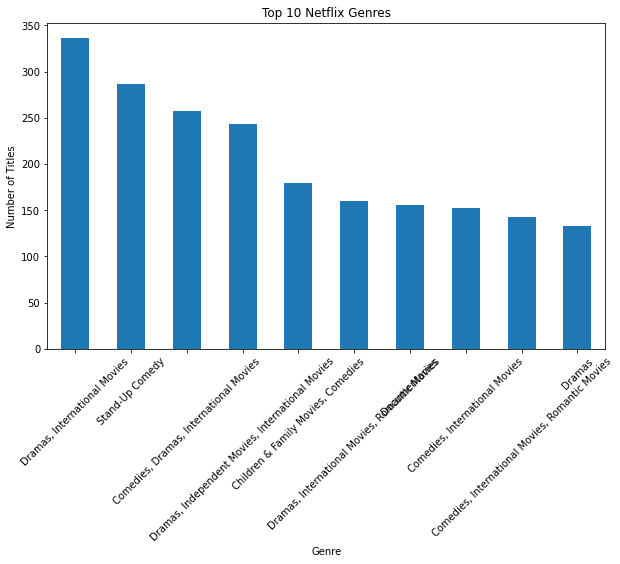

In [80]:
# Get top 10 categories
top_categories = df['listed_in'].value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
top_categories.plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

### ✅ Insight 1: Movies dominate Netflix content

The bar chart above shows that movies (over 5000 titles) significantly outnumber TV shows (fewer than 300 titles).  
This indicates that movies overwhelmingly dominate the dataset, with very limited representation of TV shows.

### ✅ Insight 2: Rapid growth in content after 2015

The "Content Added Over Time" line chart above shows a sharp increase in the number of titles added after 2015, with a peak around 2019–2020.  
This indicates that Netflix expanded its content library significantly during this period.

### ✅ Insight 3: Movies account for the vast majority of all content

The pie chart above shows that movies make up approximately 97.2% of the dataset, while TV shows account for only about 2.8%.  
This highlights an overwhelming dominance of movies, indicating that the dataset contains very few TV shows after the cleaning process.


### ✅ Insight 4: Most content is recent (post-2000)

The histogram above shows that the majority of Netflix content was released after the year 2000, with a strong concentration between 2015 and 2020.
This indicates that Netflix focuses more on modern and recently produced content, likely to align with current audience preferences and industry trends.


### ✅ Insight 5: Presence of older content as outliers

The boxplot above reveals that most release years are concentrated in recent decades, while a few very old titles appear as outliers.
This suggests that although Netflix primarily hosts modern content, it also includes some classic or older titles, adding diversity to its catalog.


### ✅ Insight 6: United States dominates content production

**The bar chart clearly shows that the United States has the highest number of Netflix titles, far exceeding all other countries, with India as a distant second.**  
Countries like the United Kingdom, Canada, Spain, Egypt, Nigeria, Japan, Turkey, and Indonesia contribute significantly fewer titles, forming a long tail distribution.

This sharp drop after the top two countries highlights a strong imbalance, indicating that Netflix content production is heavily concentrated in a few key regions—especially the United States—while other countries have relatively limited representation.


### ✅ Insight 7: Drama and Comedy dominate Netflix genres

**The bar chart above shows that drama-related and comedy-related categories appear most frequently, with combinations like "Dramas, International Movies" and "Stand-Up Comedy" leading the distribution.**  
Other genre combinations such as comedy-dramas, international films, and family movies also appear frequently, but with slightly lower counts.

This pattern suggests that Netflix heavily prioritizes **dramatic and comedic content**, often blending multiple genres to cater to diverse audience preferences and global markets.


In [83]:
df.to_csv('cleaned_netflix.csv', index=False)